In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import mat73
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import ttest_rel
from itertools import chain
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
%load_ext autoreload
%autoreload 2

parent_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
sys.path.append(parent_dir)
from GLM_regression import *
from GLM_regression_plotting import *
plt.rcParams.update({'font.size': 12,
                     'axes.spines.right': False,
                     'axes.spines.top':   False,
                     'legend.frameon':    False,})

In [2]:
datasets_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir, "datasets"))
filename_SST = "SSTindivsomata_GLM"
filepath_SST = os.path.join(datasets_dir, filename_SST+".mat")


datasets_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir, "datasets"))
filename_NDNF = "NDNFindivsomata_GLM"
filepath_NDNF = os.path.join(datasets_dir, filename_NDNF+".mat")


datasets_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir, "datasets"))
filename_EC = "EC_GLM"
filepath_EC = os.path.join(datasets_dir, filename_EC+".mat")

In [3]:
activity_dict_SST, factors_dict_SST = preprocess_data(filepath_SST, normalize=True)
activity_dict_NDNF, factors_dict_NDNF = preprocess_data(filepath_NDNF, normalize=True)
activity_dict_EC, factors_dict_EC = preprocess_data(filepath_EC, normalize=True)

In [4]:
#DO NOT RUN THIS CELL IF YOU WANT TO INCLUDE ALL VARIABLES IN THE GLM 

#options: "Velocity", "Licks", "Reward_loc", Position_bin_1 ... Position_bin_10

filtered_factors_dict_SST = subset_variables_from_data(factors_dict_SST, variables_to_keep=["Velocity"])
filtered_factors_dict_NDNF = subset_variables_from_data(factors_dict_NDNF, variables_to_keep=["Velocity"])
filtered_factors_dict_EC = subset_variables_from_data(factors_dict_EC, variables_to_keep=["Velocity"])


In [5]:

GLM_params_SST, predicted_activity_dict_SST = fit_GLM_population(filtered_factors_dict_SST, activity_dict_SST, quintile=None, regression='ridge', renormalize=True, alphas=None)

GLM_params_NDNF, predicted_activity_dict_NDNF = fit_GLM_population(filtered_factors_dict_NDNF, activity_dict_NDNF, quintile=None, regression='ridge', renormalize=True, alphas=None)
    
GLM_params_EC, predicted_activity_dict_EC = fit_GLM_population(filtered_factors_dict_EC, activity_dict_EC, quintile=None, regression='ridge', renormalize=True, alphas=None)
  

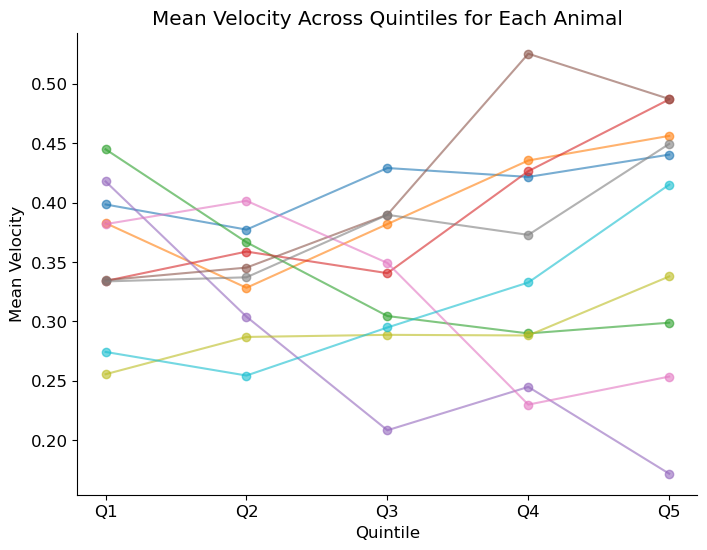

In [6]:

plot_velocity_across_quintiles_per_animal(filtered_factors_dict_SST)


(50,)


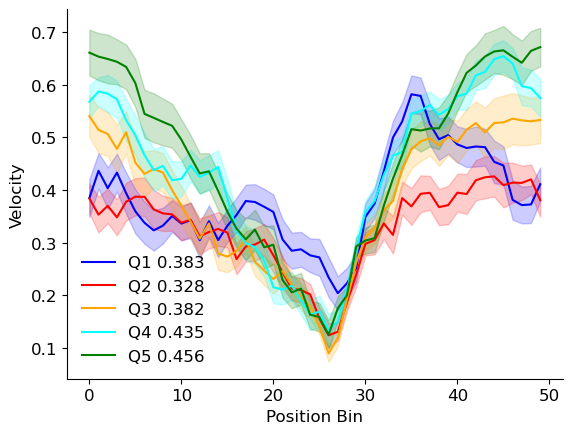

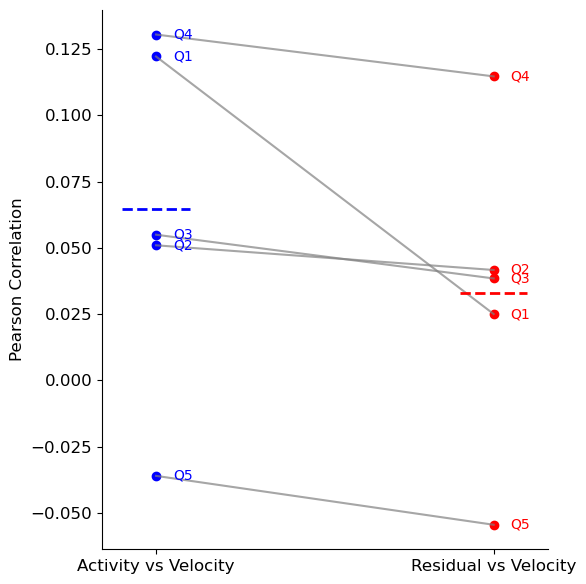

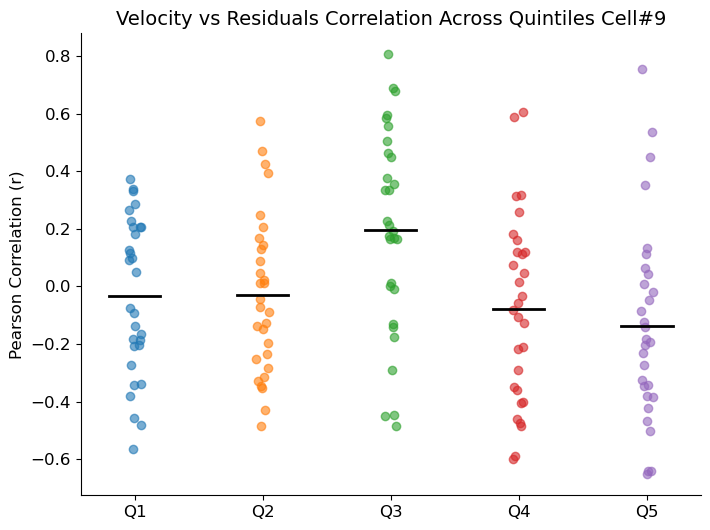

In [7]:

confirm_model(GLM_params_SST, factors_dict_SST, filtered_factors_dict_SST, predicted_activity_dict_SST, activity_dict_SST, cell_number=9, variable_to_correlate_list=["Licks", "Reward_loc", "Velocity"], variable_into_GLM="Velocity", cell_type="SST", quintile="Q5")


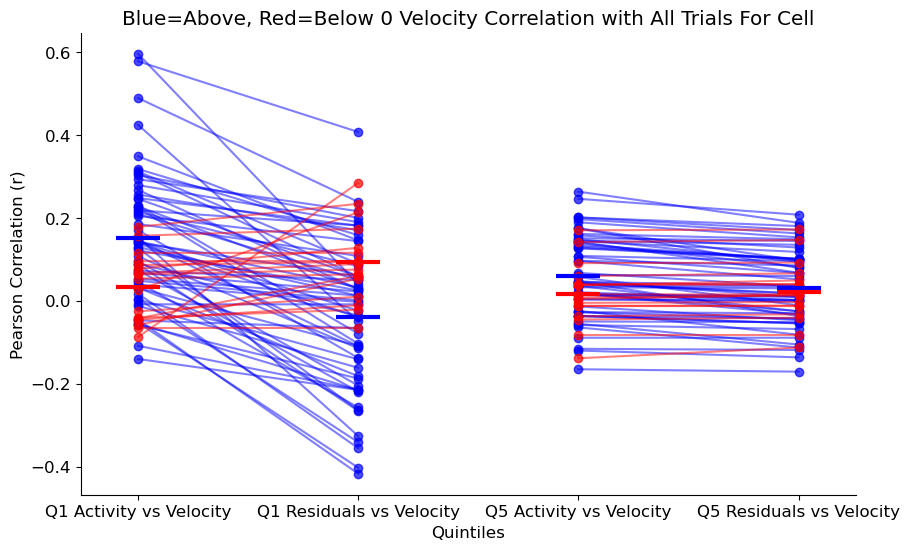

In [8]:

get_q1_q5_residuals_all_cells(GLM_params_SST, factors_dict_SST, filtered_factors_dict_SST, predicted_activity_dict_SST, activity_dict_SST, variable_into_GLM="Velocity")
    

<Figure size 1000x600 with 0 Axes>

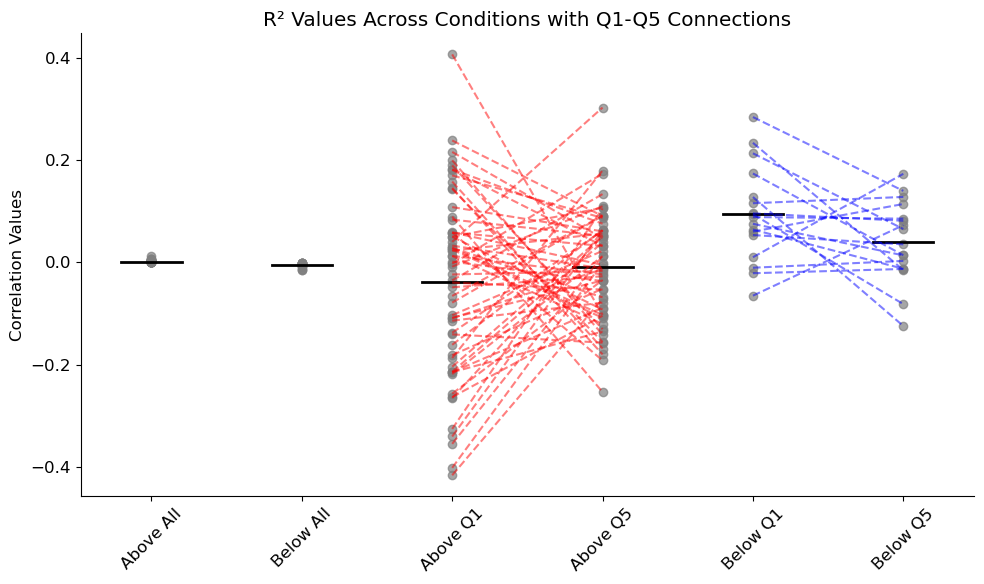

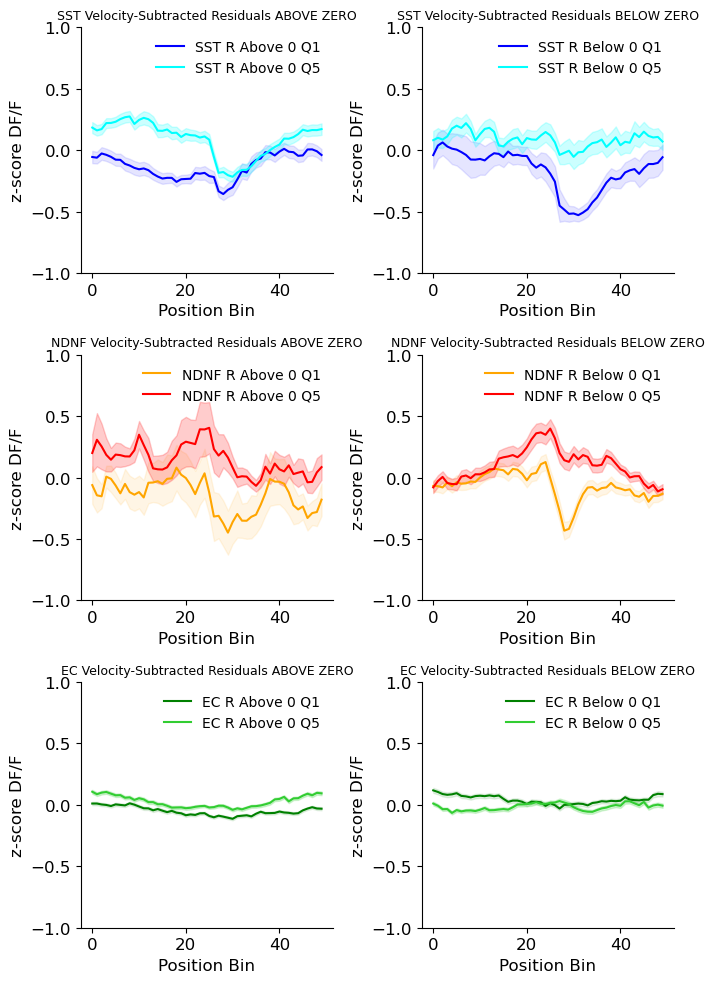

In [9]:

plot_r2_above_below_per_animal_with_learning(activity_dict_SST, predicted_activity_dict_SST, filtered_factors_dict_SST, activity_dict_NDNF, predicted_activity_dict_NDNF, filtered_factors_dict_NDNF, activity_dict_EC, predicted_activity_dict_EC, filtered_factors_dict_EC, residual=True)


In [10]:


velocity_per_cell_dict = {}
trial_av_velocity_per_cell_dict = {}
      
for animal in activity_dict_SST:
    velocity_per_cell_dict[animal] = {}
    trial_av_velocity_per_cell_dict[animal] = {}
    for neuron in activity_dict_SST[animal]:
        velocity_per_cell_dict[animal][neuron] = factors_dict_SST[animal]["Velocity"]
        trial_av_velocity_per_cell_dict[animal][neuron] = np.mean(factors_dict_SST[animal]["Velocity"], axis=1)
      

print(trial_av_velocity_per_cell_dict.keys())
print(trial_av_velocity_per_cell_dict["animal_1"].keys())
print(trial_av_velocity_per_cell_dict["animal_1"]["cell_2"].shape)

dict_keys(['animal_1', 'animal_2', 'animal_3', 'animal_4', 'animal_5', 'animal_6', 'animal_7', 'animal_8', 'animal_9', 'animal_10'])
dict_keys(['cell_2', 'cell_3', 'cell_4', 'cell_5', 'cell_6'])
(50,)


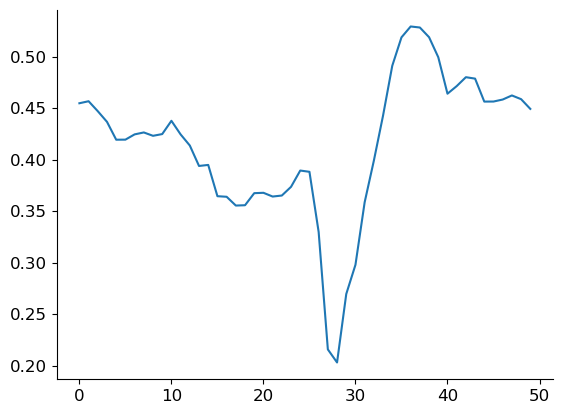

In [11]:
plt.plot(trial_av_velocity_per_cell_dict["animal_1"]["cell_2"])

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from pygam import GAM, s
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV

def compare_GLM_GAM(factors_dict, activity_dict, regression='ridge', alphas=None):
   
    results_dict = {}

    for animal in factors_dict:
        results_dict[animal] = {}

        for neuron in activity_dict[animal]:
            results_dict[animal][neuron] = {'GLM_R2': [], 'GLM_PearsonR': [], 
                                            'GAM_R2': [], 'GAM_PearsonR': []}

            for quintile in range(5):
                num_trials = activity_dict[animal]['Velocity'].shape[1]
                quintile_indices = np.array_split(np.arange(num_trials), 5)[quintile]
                start_idx, end_idx = quintile_indices[0], quintile_indices[-1] + 1

                _factors_dict = {var: factors_dict[animal][var][:, start_idx:end_idx] for var in factors_dict[animal]}
                neuron_activity = activity_dict[animal][neuron][:, start_idx:end_idx]

                velocity_flat = _factors_dict['Velocity'].flatten()
                activity_flat = neuron_activity.flatten()

                neuron_GLM_params, neuron_predicted_activity = fit_GLM(_factors_dict, neuron_activity, regression, alphas)
                results_dict[animal][neuron]['GLM_R2'].append(neuron_GLM_params['R2'])
                results_dict[animal][neuron]['GLM_PearsonR'].append(neuron_GLM_params['pearson_R'])

                gam = GAM(s(0)).fit(velocity_flat.reshape(-1,1), activity_flat)
                gam_predicted_activity = gam.predict(velocity_flat.reshape(-1,1))

                trialavg_neuron_activity = np.mean(neuron_activity, axis=1)
                trialavg_gam_activity = np.mean(gam_predicted_activity.reshape(neuron_activity.shape), axis=1)
                pearson_R = np.corrcoef(trialavg_gam_activity, trialavg_neuron_activity)[0, 1]
                gam_R2 = gam.statistics_['pseudo_r2']['explained_deviance']

                results_dict[animal][neuron]['GAM_R2'].append(gam_R2)
                results_dict[animal][neuron]['GAM_PearsonR'].append(pearson_R)

    return results_dict


# Extract R² and Pearson correlation (R) values
example_animal = list(results.keys())[1]
example_neuron = list(results[example_animal].keys())[3]

glm_r2_scores = results[example_animal][example_neuron]['GLM_R2']
gam_r2_scores = results[example_animal][example_neuron]['GAM_R2']
glm_r_values = results[example_animal][example_neuron]['GLM_PearsonR']
gam_r_values = results[example_animal][example_neuron]['GAM_PearsonR']

# Plot R² values for GLM vs. GAM
plt.figure(figsize=(7,5))
plt.plot(range(1, 6), glm_r2_scores, label="GLM R² (Linear)", marker="o", color="blue")
plt.plot(range(1, 6), gam_r2_scores, label="GAM R² (Nonlinear)", marker="o", color="red")
plt.xlabel("Trial Quintile")
plt.ylabel("Variance Explained (R²)")
plt.legend()
plt.title(f"GLM vs. GAM Model Fit (R²) for {example_animal}, {example_neuron}")
plt.show()

# Plot Pearson R values for GLM vs. GAM
plt.figure(figsize=(7,5))
plt.plot(range(1, 6), glm_r_values, label="GLM Pearson R (Linear)", marker="o", color="blue")
plt.plot(range(1, 6), gam_r_values, label="GAM Pearson R (Nonlinear)", marker="o", color="red")
plt.xlabel("Trial Quintile")
plt.ylabel("Pearson Correlation (R)")
plt.legend()
plt.title(f"GLM vs. GAM Pearson Correlation for {example_animal}, {example_neuron}")
plt.show()




NameError: name 'results' is not defined

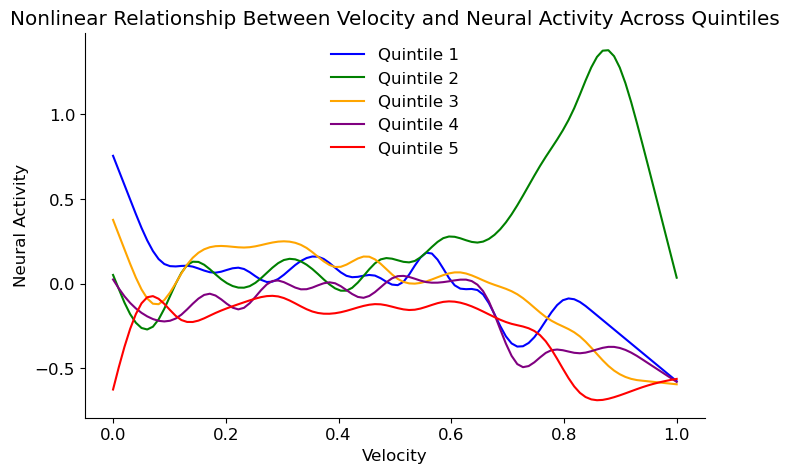

In [14]:


def fit_GAM_population(velocity_dict, activity_dict, quintile=None):
  
    gam_fits = {}

    for animal in velocity_dict:
        gam_fits[animal] = {}

        for neuron in velocity_dict[animal]:
            velocity_array = velocity_dict[animal][neuron] 
            activity_array = activity_dict[animal][neuron] 

            num_trials = velocity_array.shape[1]
            quintile_indices = np.array_split(np.arange(num_trials), 5)  

            if quintile is not None:
                start_idx, end_idx = quintile_indices[quintile][0], quintile_indices[quintile][-1] + 1
                velocity_array = velocity_array[:, start_idx:end_idx]
                activity_array = activity_array[:, start_idx:end_idx]

            velocity_flat = velocity_array.flatten()
            activity_flat = activity_array.flatten()

            gam = GAM(s(0)).fit(velocity_flat.reshape(-1,1), activity_flat)

            gam_fits[animal][neuron] = gam

    return gam_fits

gam_models = fit_GAM_population(velocity_per_cell_dict, activity_dict_SST, quintile=None)  # All trials
gam_models_q1 = fit_GAM_population(velocity_per_cell_dict, activity_dict_SST, quintile=0)  # First 20% of trials
gam_models_q5 = fit_GAM_population(velocity_per_cell_dict, activity_dict_SST, quintile=4)  # Last 20% of trials


velocity_test = np.linspace(0, 1, 100)  # Test velocity range

plt.figure(figsize=(8, 5))
colors = ["blue", "green", "orange", "purple", "red"]

for quintile in range(5):
    gam_models_q = fit_GAM_population(velocity_per_cell_dict, activity_dict_SST, quintile=quintile)
    
    example_animal = list(gam_models_q.keys())[0]
    example_neuron = list(gam_models_q[example_animal].keys())[0]
    
    gam = gam_models_q[example_animal][example_neuron]
    activity_pred = gam.predict(velocity_test.reshape(-1,1))
    
    plt.plot(velocity_test, activity_pred, color=colors[quintile], label=f"Quintile {quintile + 1}")

plt.xlabel("Velocity")
plt.ylabel("Neural Activity")
plt.title("Nonlinear Relationship Between Velocity and Neural Activity Across Quintiles")
plt.legend()
plt.show()

## fit a GAM to each quintile of data

### shape is how neural activity responds to velocity over time - shows that it is changing over time but mostly the same 
### not sure how to treat the quintile 2 data -- why velocity/activity relationship different here - artifact or learning


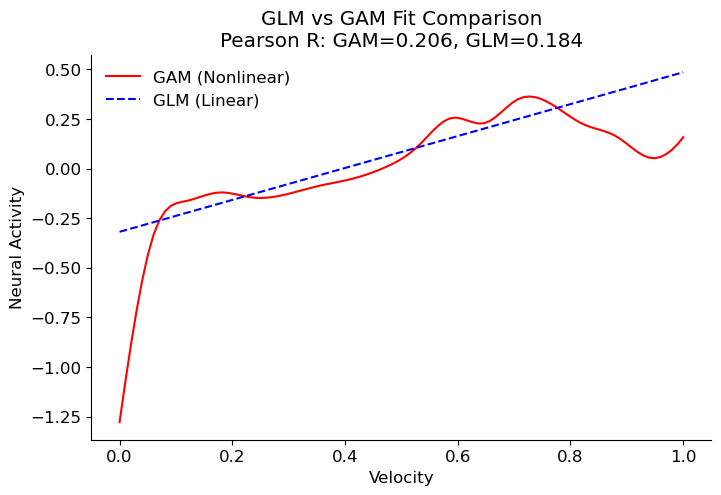

(0.18441124248007656, 0.20584410114824242)

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from pygam import LinearGAM, s
from sklearn.linear_model import Ridge
from scipy.stats import pearsonr

# Function to fit GLM
def fit_GLM_population(velocity_dict, activity_dict, quintile=None):
    glm_fits = {}

    for animal in velocity_dict:
        glm_fits[animal] = {}

        for neuron in velocity_dict[animal]:
            velocity_array = velocity_dict[animal][neuron]  
            activity_array = activity_dict[animal][neuron]  

            num_trials = velocity_array.shape[1]
            quintile_indices = np.array_split(np.arange(num_trials), 5)  

            if quintile is not None:
                start_idx, end_idx = quintile_indices[quintile][0], quintile_indices[quintile][-1] + 1
                velocity_array = velocity_array[:, start_idx:end_idx]
                activity_array = activity_array[:, start_idx:end_idx]

            velocity_flat = velocity_array.flatten().reshape(-1,1)
            activity_flat = activity_array.flatten()

            glm = Ridge(alpha=1.0)  # Using Ridge regression to fit a linear model
            glm.fit(velocity_flat, activity_flat)

            glm_fits[animal][neuron] = glm

    return glm_fits

gam_models = fit_GAM_population(velocity_per_cell_dict, activity_dict_SST, quintile=None)
glm_models = fit_GLM_population(velocity_per_cell_dict, activity_dict_SST, quintile=None)

velocity_test = np.linspace(0, 1, 100).reshape(-1,1) 

example_animal = list(gam_models.keys())[1]
example_neuron = list(gam_models[example_animal].keys())[3]

gam = gam_models[example_animal][example_neuron]
glm = glm_models[example_animal][example_neuron]

gam_activity_pred = gam.predict(velocity_test)
glm_activity_pred = glm.predict(velocity_test)

observed_activity = activity_dict_SST[example_animal][example_neuron].flatten()
velocity_flat = velocity_per_cell_dict[example_animal][example_neuron].flatten().reshape(-1,1)

glm_pred_all = glm.predict(velocity_flat)
gam_pred_all = gam.predict(velocity_flat)

glm_pearson_r, _ = pearsonr(glm_pred_all, observed_activity)
gam_pearson_r, _ = pearsonr(gam_pred_all, observed_activity)

plt.figure(figsize=(8, 5))
plt.plot(velocity_test, gam_activity_pred, label="GAM (Nonlinear)", color="red")
plt.plot(velocity_test, glm_activity_pred, label="GLM (Linear)", color="blue", linestyle="dashed")
plt.xlabel("Velocity")
plt.ylabel("Neural Activity")
plt.title(f"GLM vs GAM Fit Comparison\nPearson R: GAM={gam_pearson_r:.3f}, GLM={glm_pearson_r:.3f}")
plt.legend()
plt.show()

glm_pearson_r, gam_pearson_r
